# This Jupyter Notebook will have the same calculations but try to use the Neo-Hookean Model of elasticity instead of Young's Modulus since we're expecting some stretch.
## Inclusion of libraries:

In [119]:
#Let's add libraries:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import minimize
from scipy.optimize import fsolve
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display
from sympy import symbols, Eq, solve
from scipy.integrate import solve_ivp
import sympy as sp
import os

# **Include initial variables**

In [20]:
style={'description_width':'initial'}
#Make sure that the titles dont get truncated and the titles are important because otherwise ill forget our units
#Ok, redo all I had before but now add it all as sliders/input fields?
MaterialNameInput=widgets.Text(value='', description='Material Name:', style=style)
display(MaterialNameInput)

PermConstInput=widgets.BoundedFloatText(value=3500.0, min=0.0, max=4000.0, step=0.1, description='Perm Const (Barrer):', style=style)
display(PermConstInput)

E_Input=widgets.BoundedFloatText(value=1.5, min=0.0, max=100, step=0.1, description='Young Modulus (MPa), 100%:', style=style)
display(E_Input)

UTS_Input=widgets.BoundedFloatText(value=28, min=0.0, max=100, step=0.1, description='Ultimate Tensile Strength (MPa):', style=style) #Remember you will input MPa but must convert to Pa after !
display(UTS_Input)

rho_input=widgets.BoundedFloatText(value=0.9, min=0.0, max=100, step=0.1, description='Density (g/cm^3):', style=style)
display(rho_input)

cost_input=widgets.BoundedFloatText(value=1.6, min=0.0, max=100, step=0.1, description='Cost ($/kg):', style=style)
display(cost_input)

Shore_hardness_Input=widgets.BoundedFloatText(value=50, min=0.0, max=100, step=0.1, description='Hardness (Shore, A-Level):', style=style)
display(Shore_hardness_Input)

Temperature_Input=widgets.BoundedFloatText(value=25, min=0.0, max=100, step=0.1, description='Room temp (C):', style=style)
display(Temperature_Input)

Text(value='', description='Material Name:', style=DescriptionStyle(description_width='initial'))

BoundedFloatText(value=3500.0, description='Perm Const (Barrer):', max=4000.0, step=0.1, style=DescriptionStyl…

BoundedFloatText(value=1.5, description='Young Modulus (MPa), 100%:', step=0.1, style=DescriptionStyle(descrip…

BoundedFloatText(value=28.0, description='Ultimate Tensile Strength (MPa):', step=0.1, style=DescriptionStyle(…

BoundedFloatText(value=0.9, description='Density (g/cm^3):', step=0.1, style=DescriptionStyle(description_widt…

BoundedFloatText(value=1.6, description='Cost ($/kg):', step=0.1, style=DescriptionStyle(description_width='in…

BoundedFloatText(value=50.0, description='Hardness (Shore, A-Level):', step=0.1, style=DescriptionStyle(descri…

BoundedFloatText(value=25.0, description='Room temp (C):', step=0.1, style=DescriptionStyle(description_width=…

# **Add hard limitations for model and define some constants**

In [55]:
pi=np.pi #I would go crazy writing np.pi so I'm just replacing it

p_atm=101325 #Atmospheric pressure in Pa

R=8.3144598 #Gas constant in J/mol/K

V_lim_outgassed=4.8 #When the gas has escaped, the maximum volume cannot be below 4.8L because then there really is definitely not enough buoyancy. THis is in L here, because I change the rest of the solution to account for it (I didn't forget my units)

V_lim_initial=0.0052 #If volume is <5.2L initially, then it does not provide enough buoyancy. I mean, 5L is enough, but you want some redundancy.

V_max=0.006 #We do not want the initial volume to be >6L, because then that's too bulky for nifty rescues. ALso uses too many resources. Optimisation probably won't ever want to bring it above that but worth putting this out there, anyway.

P=3.348*1e-16*PermConstInput.value #Convert barrer to (mol m)/(m^2 s Pa)

E=E_Input.value*1e6

G=E/3

UTS=UTS_Input.value*1e6

rho=rho_input.value*1e3

cost=cost_input.value

ShoreHardness=Shore_hardness_Input.value

Temp=Temperature_Input.value+273.15 #temp in K important

Name=MaterialNameInput.value



# Optimise BCs - Neo-Hookean Model

I was initially doing the calculations with hand-inputted values and manual calculations. I then tested it with well-known numbers from a baloon, and it worked perfectly, returning values as expected. However, doing so has made me realise that I need an optimisation algorithm, in order to understand exactly how to choose r_0, T_0, etc such that it still produces the required 5-6L of volume at the start, but stays satiable. Otherwise I could hike thickness and then hike initial radius with it, without realising that I could be manually lowering both. In essence, there is too many variables for me to try and optmise everything by hand. For this, I will use the SciPy's optimise library. Here is some documentation on it, with some cool linear algebra examples:
https://docs.scipy.org/doc/scipy/tutorial/optimize.html. Here is a good, very simple CodeCademy resource that got me understanding how this works from a functional, not mathematical perspective: https://www.codecademy.com/resources/docs/scipy/scipy-optimize/minimize

Here's a good video example: https://www.youtube.com/watch?v=_aNYFXwzFno.

This is how I understand it works from reading a bit and watching some videos, but I could be very wrong. Each variable we're trying to optimise can be arranged in a vector, and given weights based on how important they are, as well as normalisation factors such that the weight of each component is only dependent on its importance. Various algorithms from the SciPy library can be used for optimisation purposes, but in our case with so many variables and wanting to use gradient search in our vector space, a SQSL algorithms should work well (and also, that's the only algorithm I've seen used in examples). We can also introduce constraints, including as functional constraints.

In [141]:
def objective_function(x): #A function for what we're actually trying to minimise
    r_0, T_0, n_0, r=x #Include variables for optimisation

    materialVolume = 4*pi*(r_0**2)*T_0
    materialMass=materialVolume*rho
    MassReactants=0.34*n_0*0.192+n_0*0.084+(n_0/0.25)*0.015 #Mass of reactant A and B, including stoichiometry plus 15mL of water for every quarter mol for reactants to dissolve. This is a hypothetical but closely resembles other gas generation systems
    return materialMass+MassReactants #We want the mass of reactants to be minimised

#Restube has a mass of ~200g (weighed by me) and TPU/Nylon has a density of roughly 1200 kg/m^3. So, the volume of the material of the restube is then 0.2/1200=0.000167 m^3. So the moles are 3 order of magnitude higher. We multiply by 1,000 then, to even out the playing field for the SLSQ algorithm; normalising the variables! ALso not that optimising the material volume will also optimise wight. I initially tried to optimise mass along with the volume until I realised they're proportional with a constant (the density) - so do not try to optimise the mass as well.

#Then, let's include some constraints:
def pressure_constraint(x):
    r_0, T_0, n_0, r=x
    #We include a constraint from the previous equations!

    #We define the restorative pressure from a Neo_hookean Model!
    lam=r/r_0

    p_res=2*G*(T_0/r_0)*(lam**(-1)-lam**(-7)) #Pretty much only thing that changes for Neo-Hookean Model

    #We also know that:
    p_gas=(3*n_0*R*Temp)/(4*pi*r**3)

    return p_gas-p_res-p_atm #And this must be 0 of course for when we set up the optimisation algorithm

def min_volume(x):
    r=x[3] #Take r from array as defined previously
    V=4/3*pi*(r**3)
    return V-V_lim_initial

def max_volume(x):
    r=x[3]
    V=4/3*pi*(r**3)
    return V_max-V #We will say that V_max-V>=0 of course

def stretch_lim(x): #We do not want the material to stretch any more than ~100% of its original volume. At that point, any material would be too stretched out and prone to popping, which wouldn't be ok in aquatic environments. So radius can't be greater than 1.26 r_0 (given the proportionalities). NB 27/4/26 - this was changed to be softer - we're allowing for a 1.4r_0 stretch to alleviate constraints. NB 16/05/2026 - ok since we're using the Neo Hookean Model now, we might as well just increase this even more hey. Make it 1.8r!!!!! (not factorials)
    r_0=x[0]
    r=x[3]
    return 1.8*r_0-r #We want the radius to be less than 1.4 r_0, so that the material is not too stretched out.

def stretch_min(x): #Very interestingly, playing around with Young's Moduli made me realise that there's no constraint to force pressures to be positive. Now, of course, we're not creating a vaccuum - we're creating gas. So we need to define a minimum stretch (the material must at least stretch outwards... Not inwards).
    r_0=x[0]
    r=x[3]
    return r-r_0

#Put all constraints together:

cons=[{'type':'eq', 'fun':pressure_constraint}, {'type':'ineq', 'fun':min_volume}, {'type':'ineq', 'fun':max_volume}, {'type':'ineq', 'fun':stretch_lim}, {'type':'ineq', 'fun':stretch_min}] #Add constraints as equalities and inequalities

#Then, I include bounds (so we can't just use a thickness of T=0. The numbers must be realistic)

bounds = (
    (0.005,0.5), #Very rough bounds for r_0
    (0.0003,0.003), #Keep T_0 it thin - from 0.3 mm to 3 mm (upper bound doesn't matter, it will never optimise for it anyway)
    (0.05,0.5), #Please no more than 0.5 moles CO2, this would require so many reactants.
    (0.01,1.4) #Give the optimisation algorithm very rough bounds of radius, r. Must be at least 0.1 though for at least 5L volume at start
)

#Ok, now that all that has been set up, here I can run the optimiser (and just pray it gives me the corrct values)

#I give initial guess (have played around with this quite a bit):
x0 = [0.09, 0.00005, 0.23, 0.1]

solution_initialValues=minimize(objective_function, x0, method='SLSQP', bounds=bounds, constraints=cons)

if solution_initialValues.success:
    opt_r_0, opt_T_0, opt_n_0, opt_r = solution_initialValues.x
    opt_V = (4/3) * pi * opt_r**3
    materialMass=4*pi*(opt_r_0**2)*opt_T_0*rho
    MassReactants=0.34*opt_n_0*0.192+opt_n_0*0.084+(opt_n_0/0.25)*0.015
    TotalMass=materialMass+MassReactants

    print("Optimisation completed")
    print(f"Optimal initial radius, r_0: {opt_r_0*1000:.1f} mm, or {opt_r_0:.2f} m")
    print(f"Optimal thickness, T_0: {opt_T_0*1000:.3f} mm, or {opt_T_0:.6f} m")
    print(f"Optimal moles: {opt_n_0:.2f} moles, or in grams of CO2, that is: {opt_n_0*44.01:.2f} g")
    print(f"Initial, blown up volume, is then: {opt_V*1000:.2f} L or {opt_V:.2f} m^3")
    #Calculate packed material mass from the area of the material initially, taken as a sphere with r_0 radius, using thickness and density to find mass of material. This was repurposed from an old cell above.
    SA=4*pi*opt_r_0**2 #Surface area of our material
    V_material=SA*opt_T_0 #Volume of our material
    MaterialMass=V_material*rho
    MaterialCost=MaterialMass*cost
    print(f"The initial mass of the packed material is {MaterialMass:.4f} kg, or {MaterialMass*1e3:.1f} g")
    print(f"The cost of the packed material is ${MaterialCost:.4f}")
    print(f"Mass of everything together is {TotalMass:.4f} kg, or {TotalMass*1e3:.1f} g")
else:
    print("Optimisation Failed:", solution_initialValues.message)


Optimisation completed
Optimal initial radius, r_0: 59.7 mm, or 0.06 m
Optimal thickness, T_0: 0.300 mm, or 0.000300 m
Optimal moles: 0.22 moles, or in grams of CO2, that is: 9.60 g
Initial, blown up volume, is then: 5.20 L or 0.01 m^3
The initial mass of the packed material is 0.0121 kg, or 12.1 g
The cost of the packed material is $0.0194
Mass of everything together is 0.0578 kg, or 57.8 g


# Optimise BCs Young's Model

In [140]:
def objective_function(x): #A function for what we're actually trying to minimise
    r_0, T_0, n_0, r=x #Include variables for optimisation

    materialVolume = 4*pi*(r_0**2)*T_0
    materialMass=materialVolume*rho
    MassReactants=0.34*n_0*0.192+n_0*0.084+(n_0/0.25)*0.015 #Mass of reactant A and B, including stoichiometry plus 15mL of water for every quarter mol for reactants to dissolve. This is a hypothetical but closely resembles other gas generation systems
    return materialMass+MassReactants #We want the mass of reactants to be minimised

#Restube has a mass of ~200g (weighed by me) and TPU/Nylon has a density of roughly 1200 kg/m^3. So, the volume of the material of the restube is then 0.2/1200=0.000167 m^3. So the moles are 3 order of magnitude higher. We multiply by 1,000 then, to even out the playing field for the SLSQ algorithm; normalising the variables! ALso not that optimising the material volume will also optimise wight. I initially tried to optimise mass along with the volume until I realised they're proportional with a constant (the density) - so do not try to optimise the mass as well.

#Then, let's include some constraints:
def pressure_constraint(x):
    r_0, T_0, n_0, r=x
    #We include a constraint from the previous equations!

    #From our calculations, we know that:
    p_res=(2*E*r_0*T_0*(r-r_0))/(r**3)

    #We also know that:
    p_gas=(3*n_0*R*Temp)/(4*pi*r**3)

    return p_gas-p_res-p_atm #And this must be 0 of course for when we set up the optimisation algorithm

def min_volume(x):
    r=x[3] #Take r from array as defined previously
    V=4/3*pi*(r**3)
    return V-V_lim_initial

def max_volume(x):
    r=x[3]
    V=4/3*pi*(r**3)
    return V_max-V #We will say that V_max-V>=0 of course

def stretch_lim(x): #We do not want the material to stretch any more than ~100% of its original volume. At that point, any material would be too stretched out and prone to popping, which wouldn't be ok in aquatic environments. So radius can't be greater than 1.26 r_0 (given the proportionalities). NB 27/4/26 - this was changed to be softer - we're allowing for a 1.4r_0 stretch to alleviate constraints.
    r_0=x[0]
    r=x[3]
    return 1.4*r_0-r #We want the radius to be less than 1.4 r_0, so that the material is not too stretched out.

def stretch_min(x): #Very interestingly, playing around with Young's Moduli made me realise that there's no constraint to force pressures to be positive. Now, of course, we're not creating a vaccuum - we're creating gas. So we need to define a minimum stretch (the material must at least stretch outwards... Not inwards).
    r_0=x[0]
    r=x[3]
    return r-r_0

#Put all constraints together:

cons=[{'type':'eq', 'fun':pressure_constraint}, {'type':'ineq', 'fun':min_volume}, {'type':'ineq', 'fun':max_volume}, {'type':'ineq', 'fun':stretch_lim}, {'type':'ineq', 'fun':stretch_min}] #Add constraints as equalities and inequalities

#Then, I include bounds (so we can't just use a thickness of T=0. The numbers must be realistic)

bounds = (
    (0.005,0.5), #Very rough bounds for r_0
    (0.0003,0.003), #Keep T_0 it thin - from 0.3 mm to 3 mm (upper bound doesn't matter, it will never optimise for it anyway)
    (0.05,0.5), #Please no more than 0.5 moles CO2, this would require so many reactants.
    (0.01,1.4) #Give the optimisation algorithm very rough bounds of radius, r. Must be at least 0.1 though for at least 5L volume at start
)

#Ok, now that all that has been set up, here I can run the optimiser (and just pray it gives me the corrct values)

#I give initial guess (have played around with this quite a bit):
x0 = [0.09, 0.00005, 0.23, 0.1]

solution_initialValues=minimize(objective_function, x0, method='SLSQP', bounds=bounds, constraints=cons)

if solution_initialValues.success:
    opt_r_0_young, opt_T_0_young, opt_n_0_young, opt_r_young = solution_initialValues.x
    opt_V_young = (4/3) * pi * opt_r_young**3
    materialMass=4*pi*(opt_r_0_young**2)*opt_T_0_young*rho
    MassReactants_young=0.34*opt_n_0_young*0.192+opt_n_0_young*0.084+(opt_n_0_young/0.25)*0.015
    TotalMass_young=materialMass+MassReactants_young

    print("Optimisation completed")
    print(f"Optimal initial radius, r_0: {opt_r_0_young*1000:.1f} mm, or {opt_r_0_young:.2f} m")
    print(f"Optimal thickness, T_0: {opt_T_0_young*1000:.3f} mm, or {opt_T_0_young:.6f} m")
    print(f"Optimal moles: {opt_n_0_young:.2f} moles, or in grams of CO2, that is: {opt_n_0_young*44.01:.2f} g")
    print(f"Initial, blown up volume, is then: {opt_V_young*1000:.2f} L or {opt_V_young:.2f} m^3")
    #Calculate packed material mass from the area of the material initially, taken as a sphere with r_0 radius, using thickness and density to find mass of material. This was repurposed from an old cell above.
    SA_young=4*pi*opt_r_0_young**2 #Surface area of our material
    V_material_young=SA_young*opt_T_0_young #Volume of our material
    MaterialMass_young=V_material_young*rho
    MaterialCost_young=MaterialMass_young*cost
    print(f"The initial mass of the packed material is {MaterialMass_young:.4f} kg, or {MaterialMass_young*1e3:.1f} g")
    print(f"The cost of the packed material is ${MaterialCost_young:.4f}")
    print(f"Mass of everything together is {TotalMass_young:.4f} kg, or {TotalMass_young*1e3:.1f} g")
else:
    print("Optimisation Failed:", solution_initialValues.message)


Optimisation completed
Optimal initial radius, r_0: 76.8 mm, or 0.08 m
Optimal thickness, T_0: 0.300 mm, or 0.000300 m
Optimal moles: 0.22 moles, or in grams of CO2, that is: 9.51 g
Initial, blown up volume, is then: 5.20 L or 0.01 m^3
The initial mass of the packed material is 0.0200 kg, or 20.0 g
The cost of the packed material is $0.0320
Mass of everything together is 0.0652 kg, or 65.2 g


# **Next, we need to check if our bladder pops at 1.5x its initial stretch**

## This can be done with Young's Modulus and Ultimate Tensile Strength - Young's Mdulus models are less forgiving than Neao-Hookean models at high stretch, so if it doesn't pop with the Young's Model, then it won't pop at all

### We know from our maths, that $\sigma = \frac{F}{\tilde{A}} = \frac{\gamma}{T}$

### We also know that $p_{res}=\frac{2\gamma}{r}$

### $\therefore \sigma=\frac{rp_{res}}{2T}$

### $\therefore$ If $\sigma>UTS$ where UTS is the ultimate tensile strength, then the material rips!

In [58]:
#Calculate stretched thickness right after inflation at t=0:

T_inflated =((opt_T_0* opt_r_0**2))/(opt_r**2)

#Calculate p_res in same sort of situation:
p_res_inflated=(2*E*opt_r_0*opt_T_0*(opt_r-opt_r_0))/(opt_r**3)

#Then from this we can calculate the current stress (sigma, (Pa)):
InflatedStress=(opt_r*p_res_inflated)/(2*T_inflated)

print(f'The inflated stress is {InflatedStress:.2e} Pa and is {InflatedStress*1.5:.2e} Pa at 1.5x the original stress')

print(f'Ultimate Tensile Strength is {UTS:.2e} Pa')

if InflatedStress*1.5>UTS:
    print("The material has popped at 1.5x the original stress... Not ideal go figure something out.")
else:
    print("The material has not popped (yippee)")


The inflated stress is 1.20e+06 Pa and is 1.80e+06 Pa at 1.5x the original stress
Ultimate Tensile Strength is 2.80e+07 Pa
The material has not popped (yippee)


# We're overthrowing all the previous manual calculations and making the computer do grunt work. The following is solely for a mathematical representation and should be skipped after the analytical answer has been confirmed.

Let's try to recalculate except this time we do absolutely everything symbollically and from the ground up, because the math is too messy on paper. Use the sympy library for this. FIrst do everything symbolically so we can check over the final result

In [76]:
#First, define every symbol - first I just want it to spit out the equation so I can have a look and see if it... 'Looks' correct?:

r_sym, t_sym, r_0_sym, T_0_sym, G_sym, P_sym, R_sym, Temp_sym, p_atm_sym = sp.symbols('r t r_0 T_0 G P R T_temp p_atm', positive=True)

#Start building equations:

lam_sym = r_sym/r_0_sym

p_res_sym=2*G_sym*(T_0_sym/r_0_sym)*(lam_sym**(-1)-lam_sym**(-7))

T_current_sym=(T_0_sym*r_0_sym**2)/r_sym**2

#Defining dn/dt as per the paper calculations

dn_dt_sym = -(P_sym*(p_res_sym+p_atm_sym)*4*sp.pi*r_sym**2)/T_current_sym

#Defining n(r) exactly as it was on paper (nothing has really changed here)
#pV=nRT_temp, so n=pV/RT_temp. p=p_res+p_atm
n_sym=(p_res_sym+p_atm_sym)*sp.Rational(4,3)*(sp.pi*r_sym**3)/(R_sym*Temp_sym)

dn_dr_sym=sp.diff(n_sym,r_sym)

#Chain rule
dr_dt_sym=dn_dt_sym/dn_dr_sym

#Then simplify:
dr_dt_simple=sp.simplify(dr_dt_sym)

print('So we get that dr/dt is:')
print(sp.latex(dr_dt_simple))
print('Without LaTeX, that is:')
print(dr_dt_simple)

#Then substitute actual values in (or all we know):

subs={
    G_sym:G,
    r_0_sym:opt_r_0,
    T_0_sym:opt_T_0,
    P_sym:P,
    R_sym:R,
    Temp_sym:Temp,
    p_atm_sym:p_atm
}

dr_dt_subbed=dr_dt_simple.subs(subs)


So we get that dr/dt is:
\frac{3 P R T_{temp} r^{2} \left(- 2 G T_{0} r^{6} + 2 G T_{0} r_{0}^{6} - p_{atm} r^{7}\right)}{T_{0} r_{0}^{2} \cdot \left(4 G T_{0} r^{6} + 8 G T_{0} r_{0}^{6} + 3 p_{atm} r^{7}\right)}
Without LaTeX, that is:
3*P*R*T_temp*r**2*(-2*G*T_0*r**6 + 2*G*T_0*r_0**6 - p_atm*r**7)/(T_0*r_0**2*(4*G*T_0*r**6 + 8*G*T_0*r_0**6 + 3*p_atm*r**7))


# Define Model Needs/Wants

Do we want to plot over a range of temperatures? What Model do we want to use?

In [149]:
#First we will define dr/dt as a python function of parameters t and r of course:
checkboxTemp = widgets.Checkbox(
    value=False,
    description='Plot a Range of Temperatures',
    disabled=False
)

checkboxNeoHook = widgets.Checkbox(
    value=True,
    description='Neo-Hookean Model',
    disabled=False
)

checkboxYoungMod = widgets.Checkbox(
    value=False,
    description='Young\'s Modulus Model',
    disabled=False
)

checkboxSaveGraph = widgets.Checkbox(
    value=True,
    description='Save Graph',
    disabled=False
)

timeRangeInput=widgets.BoundedFloatText(value=8400, min=0.0, max=20000, step=10, description='Time Range for Plotting:', style=style)
display(timeRangeInput)
display(checkboxTemp)
display(checkboxNeoHook)
display(checkboxYoungMod)
display(checkboxSaveGraph)

timeLength=4000 #Change this to change the timescale over which you want to look over. In seconds. 86400 is 24hrs

BoundedFloatText(value=8400.0, description='Time Range for Plotting:', max=20000.0, step=10.0, style=Descripti…

Checkbox(value=False, description='Plot a Range of Temperatures')

Checkbox(value=True, description='Neo-Hookean Model')

Checkbox(value=False, description="Young's Modulus Model")

Checkbox(value=True, description='Save Graph')

# Do all the magic and plot it

Reached threshold volume at 0.0257 hrs or 1.54 minutes.
Reached threshold volume at 0.0444 hrs or 2.66 minutes.


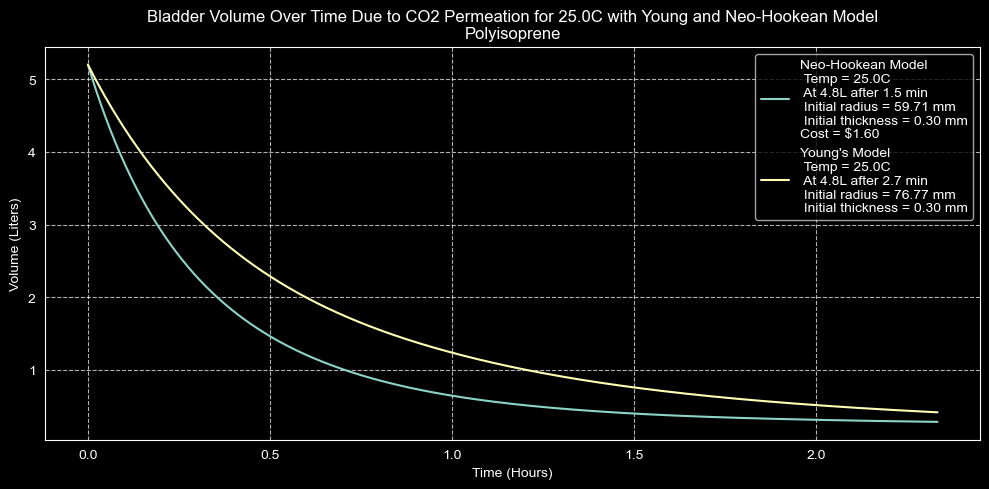

In [150]:
plotRangeTemps=checkboxTemp.value

plotNeo=checkboxNeoHook.value

plotYoung=checkboxYoungMod.value

timeLength=timeRangeInput.value

saveGraph=checkboxSaveGraph.value

plt.figure(figsize=(10,5)) #Create figure, arb figsize for now

tRange=(0,timeLength) #Define integration bounds

tEval=np.linspace(0,timeLength,1000) #We evaluate the time range over 24 hrs

currentTemperature=Temp #First set temperature as the initial temp as per our input - always set to room temp, cnt be bothered to change input

timeAtThreshold=0

#Make the titles good for both the filename and the graph title

if plotRangeTemps:
    titleTemp='a Range of Temperatures'
else:
    titleTemp=f'{currentTemperature-273.15}C'

if plotYoung and plotNeo:
    titleModel='Young and Neo-Hookean'
elif plotNeo:
    titleModel=f'Only a Neo-Hookean'
else:
    titleModel=f'Only Youngs'


#Save file to designated folder with filename defined

output_folder = r"C:\Users\nikol\OneDrive - Australian National University\Documents\University\Y3S1\TaSP\Big Project"

fileName=f'{Name}_{titleTemp}_{titleModel} Model Over Time Range {timeLength}.png'

savePath=os.path.join(output_folder,fileName)


def plotLabelNeoHookean(tempLabel, intersectPoint):
    labelNeo=f'Temp = {tempLabel-273.15}C \n At 4.8L after {intersectPoint:.1f} min\n Initial radius = {opt_r_0*1e3:.2f} mm\n Initial thickness = {opt_T_0*1e3:.2f} mm\nCost = ${cost:.2f}'

    return labelNeo

def plotLabelYoung(tempLabelYoung, intersectPointYoung):
    labelYoung=f'Temp = {tempLabelYoung-273.15}C \n At 4.8L after {intersectPointYoung:.1f} min\n Initial radius = {opt_r_0_young*1e3:.2f} mm\n Initial thickness = {opt_T_0_young*1e3:.2f} mm'

    return labelYoung



def dr_dt(t,r): #This is for the neo-hookean model, just can't be bothered to change the funx name

    dRdT=3*P*R*currentTemperature*r**2*(-2*G*opt_T_0*r**6 + 2*G*opt_T_0*opt_r_0**6 - p_atm*r**7)/(opt_T_0*opt_r_0**2*(4*G*opt_T_0*r**6 + 8*G*opt_T_0*opt_r_0**6 + 3*p_atm*r**7))
    #Just copy and pasted this expression from results of sympy work from above cell

    return dRdT #Pretty simple - we just plug in what we've aready optimised for, set up our insane equation, and leave the function in terms of t and r for numerical solutions

def plotCurve_Neo():
    if plotNeo:
        solution=solve_ivp(fun=dr_dt,t_span=tRange,y0=[opt_r],t_eval=tEval)

        time_hr=solution.t/3600 #Convertin s to hr for graphing

        rVals=solution.y[0] #Save the radii as a numpy array

        V_vals_m3=(4/3)*pi*rVals**3 #Figure out the volumes
        V_vals_L=V_vals_m3*1e3 #Figure out the volumes in L

        for i in range(len(V_vals_L)):

            if V_vals_L[i] <= 4.8:
                print(f"Reached threshold volume at {time_hr[i]:.4f} hrs or {time_hr[i]*60:.2f} minutes.")
                timeAtThreshold=time_hr[i] #This is in hours
                break  # Stop loop straight after it hits

        currentLabel=plotLabelNeoHookean(tempLabel=currentTemperature, intersectPoint=timeAtThreshold*60)
        plt.plot(time_hr,V_vals_L, label=f'Neo-Hookean Model \n {currentLabel}')

def dr_dt_Young(t,r):
    num=3*P*R*currentTemperature*r*(2*E*opt_r_0_young*opt_T_0_young*(r-opt_r_0_young)+r**3*p_atm)

    denom=opt_r_0_young**2*opt_T_0_young*(2*E*opt_r_0_young*opt_T_0_young+3*r**2*p_atm)

    dRdT=-num/denom

    return dRdT

def plotCurve_Young():
    if plotYoung:
        solution=solve_ivp(fun=dr_dt_Young,t_span=tRange,y0=[opt_r],t_eval=tEval)

        time_hr=solution.t/3600 #Convertin s to hr for graphing

        rVals=solution.y[0] #Save the radii as a numpy array

        V_vals_m3=(4/3)*pi*rVals**3 #Figure out the volumes

        V_vals_L=V_vals_m3*1e3 #Figure out the volumes in L

        for i in range(len(V_vals_L)):
            if V_vals_L[i] <= 4.8:
                print(f"Reached threshold volume at {time_hr[i]:.4f} hrs or {time_hr[i]*60:.2f} minutes.")
                timeAtThreshold=time_hr[i] #This is in hours
                break  # Stop loop straight after it hits

        currentLabelYoung=plotLabelYoung(tempLabelYoung=currentTemperature, intersectPointYoung=timeAtThreshold*60)

        plt.plot(time_hr,V_vals_L, label=f'Young\'s Model\n {currentLabelYoung}')


if plotRangeTemps:
    currentTemperature=283.15 #10C in K - start from 10C
    for i in range(6): #Recreate simulation for different temperatures from -10C to 25C
        plotCurve_Neo()
        plotCurve_Young()
        currentTemperature=currentTemperature+10
else:
    plotCurve_Neo()
    plotCurve_Young()


plt.title(f'Bladder Volume Over Time Due to CO2 Permeation for {titleTemp} with {titleModel} Model\n{Name}')
plt.xlabel('Time (Hours)')
plt.ylabel('Volume (Liters)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()

if saveGraph:
    plt.savefig(savePath, dpi=300, bbox_inches='tight')

plt.show()
